# ARGUS-FEDER — Getting started with DIII-D disruption data

This notebook introduces the stored **disruption index**: twenty DIII-D shots
run through [disruption-py](https://github.com/MIT-PSFC/disruption-py), the
MIT-PSFC disruption-warning code, with every signal fetched over the Fusion
Data Platform.

A tokamak plasma is confined by magnetic fields. A **disruption** is a sudden,
uncontrolled loss of that confinement — the plasma current collapses in
milliseconds, dumping its stored energy into the machine wall. Predicting them
early enough to act is one of the field's open problems.

Every question below is typed in plain English into a `%%ask` cell. The agent
decides what to look up, writes and runs its own code, and reports back.
**Nothing here requires you to write code.**

Questions are marked `--review`: before an answer reaches you, a grader
sub-agent checks it against a stated rubric and sends it back for revision if
it fails. Watch for the verdict panel under each answer.

#### Step 1 — Prepare your session (one-time)

Run the cell below. **Your session will restart automatically — that is
expected.** Once it comes back, carry on with Step 2.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


#### Step 2 — Choose your AI model

Pick one and run the cell (defaults to a free NRP model).

In [1]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "deepseek-v4-flash",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
# LLM = {
#     "model": "glm-5",
#     "url": "https://api.z.ai/api/coding/paas/v4",
#     "api_key_env": "ZAI_API_KEY",
# }

#### Step 3 — Add your keys

Click the key icon in the left sidebar and add your secrets (toggle
"Notebook access" on for each):

- The API key matching what you picked in Step 2 (e.g. `NRP_API_KEY`)
- **Optional:** your DIII-D Pelican access token, named `FDP_TOKEN`. Every
  question in this notebook is answered from the stored index and needs no
  raw-signal access.

#### Step 4 — Install ARGUS-FEDER

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/argus_feder/main/install.py'
).read().decode(), globals())

Setting up ARGUS-FEDER...
  • Installing DIII-D data access (~1-2 min, one-time)
    ..............
    .....
  • DIII-D data access ready
  • Pelican token loaded
  • Installing the ARGUS agent (~1 min the first time)
ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded NRP_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 16 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, local-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:deepseek-v

In [ ]:
%reset

#### Step 5 — Upload the disruption index

The questions read from one SQLite file, which is not bundled with the
installer. Open the **file browser** (folder icon, left sidebar) and drag it
in; it lands in `/content/`, where the skill looks automatically.

| file | size | needed for |
|---|---|---|
| `disruption.sqlite` | ~2 MB | every question |

The upload takes seconds, but **must be repeated for each fresh Colab
session** — Colab discards local files when the runtime is recycled.

Do not mount Google Drive for this: uploading one small file per session is
faster than the mount flow and does not hand the notebook access to your whole
Drive.

#### Step 6 — Confirm the index was found

Plain Python, no agent. Prints the file it located, its provenance, and the
coverage every answer below is conditional on.

In [3]:
import os, sys
sys.path.insert(0, os.path.expanduser("~/.deepagents/agent/skills/d3d-disruption"))
from d3d_disruption import index_info, locate_disruption_db

print("database:", locate_disruption_db())
i = index_info()
print(f"{i['n_shots']} shots ({i['n_disrupted']} disrupted), {i['n_sample_rows']:,} sample rows")
print(f"produced by {i['package']} {i['version']} @ {i['commit_sha'][:8]} on {i['produced_at'][:10]}")
print()
print(i['coverage_note'])

database: /content/disruption.sqlite
20 shots (10 disrupted), 3,778 sample rows
produced by disruption_py 0.15.0.dev0 @ 9987784e on 2026-08-19

20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.


## Where does this data come from, and what does it cover?

*orientation · **answerable***

In [4]:
%%ask --review
What disruption data is available for DIII-D? Tell me where it came from,
which code produced it and at what version, how many shots it covers, and how
many of those disrupted.

I'll consult the d3d-disruption skill, which covers exactly this question.



The skill is clear. Let me check the skill directory for the helper module and database location.



Let me read the helper module to understand the database location and functions.



The skill module is clear. Let me write a script to query the disruption index for provenance and coverage.



Running the overview script to pull provenance and coverage from the index.



The query succeeded. Let me pull the disruption times for the 10 disrupted shots and confirm the parameter count.



Running the script to list disruption times and confirm parameter counts.



All data retrieved. Here is the complete picture of the DIII-D disruption index.

## DIII-D disruption data — what's available

The available data is a **disruption index** built from disruption-py output: for each covered shot it stores a time series of **63 physics parameters** sampled through the discharge (plasma current, q95, betas, radiated power, n=1 mode amplitude, stored energy, densities, shape/peaking factors, etc.), plus a disruption label and disruption time. It is stored as a local SQLite database (`disruption.sqlite`, found at `/content/disruption.sqlite`) with **3,778 sample rows** total.

## Provenance

**Source file** : `d3d_disruption_example.nc` — a NetCDF produced by running disruption-py on DIII-D data, ingested into the index on 2026-08-19T20:46:49+00:00.

**Producing code** : `disruption_py`, version **0.15.0.dev0** , pinned to commit `9987784e78ef9736e2fe42142683b3458ff38d8d` (https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d). Produced by `sammuli` on `omega06.gat.com` at 2026-08-19T07:36:50.

## Coverage

**Shots covered** : 20 (shot range 194000–199687).
**Disrupted** : 10 of the 20.

The 10 disrupted shots and their disruption times:

| Shot | Disruption time (s) | Shot | Disruption time (s) |
|---|---|---|---|
| 194000 | 0.830 | 195516 | 1.218 |
| 194128 | 5.627 | 195768 | 5.297 |
| 194292 | 4.332 | 195985 | 4.800 |
| 194464 | 3.184 | 196347 | 5.476 |
| 194649 | 3.352 | 194968 | 1.121 |

## Important caveats

- **This is a constructed slice, not a sample of DIII-D.** The 20 shots are deliberately balanced 10 disrupted / 10 not, so the 10/20 split describes the slice only and says nothing about how often DIII-D disrupts. No archive-wide disruption rate can be computed from this file.
- **The disruption label is human-curated.** It comes from `time_until_disrupt` in the d3drdb disruptions table. disruption-py's own derived estimate (`current_quench_time`, from the Ip decay) disagrees on 3 shots — 198244, 198643, 199062 — which are unlabelled in d3drdb but receive a finite derived quench time. The curated label is the authoritative one.
- **3 of the 63 parameters are flagged unusable** (`time_domain`, `ip_error`, `dipprog_dt`) — upstream disruption-py defects that return plausible but wrong values; the index blocks them by default. The remaining 60 parameters are usable.
- **A shot absent from the index is not a shot that didn't disrupt** — it simply hasn't been run through disruption-py here.

## Which shots disrupted, and when?

*labels · **answerable***

In [5]:
%%ask --review
List the shots in the disruption index. For each one, say whether it
disrupted and at what time, and show me the range of disruption times across
the disrupted shots.

I'll consult the d3d-disruption skill to get the exact query interface for the disruption index.



Let me check the helper module to confirm the exact return shape of `shots()`.



The skill provides a clean `shots()` interface. Writing a script to list all shots with disruption status/times and compute the disruption-time range.



Running the script to list all shots and compute the disruption-time range.



All 20 shots retrieved with their disruption status and times. Here is the full listing.

## Shots in the disruption index

The index covers **20 shots** (range 194000–199687), **10 disrupted / 10 not** . All disruption times come from the authoritative label, `time_until_disrupt` (the human-curated d3drdb disruptions table).

| Shot | Disrupted | Disruption time (s) |
|---|---|---|
| 194000 | yes | 0.830 |
| 194005 | no | — |
| 194128 | yes | 5.627 |
| 194292 | yes | 4.332 |
| 194464 | yes | 3.184 |
| 194649 | yes | 3.352 |
| 194869 | no | — |
| 194968 | yes | 1.121 |
| 195243 | no | — |
| 195516 | yes | 1.218 |
| 195768 | yes | 5.297 |
| 195805 | no | — |
| 195985 | yes | 4.800 |
| 196273 | no | — |
| 196347 | yes | 5.476 |
| 198244 | no | — |
| 198643 | no | — |
| 199062 | no | — |
| 199359 | no | — |
| 199687 | no | — |

## Range of disruption times

Across the 10 disrupted shots, disruption times span **0.830 s to 5.627 s** (a span of 4.797 s). Sorted, they are:

0.830, 1.121, 1.218, 3.184, 3.352, 4.332, 4.800, 5.297, 5.476, 5.627 s

The earliest disruption is shot 194000 at 0.830 s; the latest is shot 194128 at 5.627 s.

**Coverage note** : this is a constructed slice of 20 shots, deliberately balanced 10/10 — the counts describe the slice only and say nothing about how often DIII-D disrupts overall.

---
# 2. Understanding the measurements

## What do these parameters actually mean?

*semantics · **answerable***

The source files carry no units and no descriptions — that information lives in
the index's own parameter dictionary.

In [6]:
%%ask --review
What physics parameters does the disruption index record? Group them by
what produces them, and for a few of the important ones — plasma current, q95,
stored energy, normalised beta — tell me what each means and what units it is
in.

Reading the d3d-disruption skill to find the parameter-listing interface.



Reading the skill's helper module to understand the parameter-listing interface.



The skill exposes `parameters(method=...)` for grouping and `parameter_info(name)` for meaning/units. Writing a script to list all parameters grouped by producing method and pull details for the four key ones.



Running the parameter report script.



All 63 parameters retrieved and grouped by their producing method. Here is the full breakdown.

## The parameter dictionary

The disruption index records **63 physics parameters** sampled as time series through each shot. The source NetCDF carries **no semantic metadata** (no units, long names, or descriptions on any variable) — that layer lives only in the dataset's HTML writeup, and this index is where it became queryable. Each parameter is tagged with the disruption-py method that produced it, its units, meaning, and a usability flag.

**Units convention** : an explicit unit string; `1` for a dimensionless quantity; `NULL` only when genuinely unknown. In this slice: 37 explicit, 26 dimensionless, 0 unknown.

## Grouped by what produces them

The 14 groups correspond to the disruption-py method that produced each column. **60 of 63 parameters are usable** ; the 3 flagged unusable are marked below.

**Equilibrium reconstruction — `get_efit_parameters` (14 params)**
`beta_n` (normalised beta), `beta_p` (poloidal beta), `chisq` (EFIT fit quality), `dbetap_dt`, `dli_dt`, `dwmhd_dt`, `kappa` (elongation), `li` (internal inductance), `lower_gap`, `q0` (safety factor on axis), `q95`, `qstar`, `upper_gap`, `wmhd` (stored magnetic energy)

**Plasma current — `get_ip_parameters` (5 params, 3 usable)**
`dip_dt`, `ip` (measured plasma current), `ip_prog` (programmed current, MA); `dipprog_dt` and `ip_error` are **unusable** (upstream unit defects — see below)

**Real-time equilibrium — `get_rt_efit_parameters` (5 params)**
`beta_p_rt`, `chisq_rt`, `li_rt`, `q95_rt`, `wmhd_rt`

**Real-time plasma current — `get_rt_ip_parameters` (5 params)**
`dip_dt_rt`, `dipprog_dt_rt`, `ip_error_rt`, `ip_prog_rt`, `ip_rt`

**Density — `get_density_parameters` (3 params)**
`dn_dt`, `greenwald_fraction`, `n_e` (line-averaged electron density)

**Real-time density — `get_rt_density_parameters` (3 params)**
`dn_dt_rt`, `greenwald_fraction_rt`, `n_e_rt`

**Power — `get_power_parameters` (4 params)**
`p_ech`, `p_nbi`, `p_rad` (radiated power, bolometry), `radiated_fraction`

**n=1 mode — `get_n1_bradial_parameters` / `get_n1rms_parameters` (4 params)**
`n1rms`, `n1rms_normalized`, `n_equal_1_mode`, `n_equal_1_normalized`

**Peaking factors — `get_peaking_factors` (4 params)**
`ne_peaking_cva_rt`, `prad_peaking_cva_rt`, `prad_peaking_xdiv_rt`, `te_peaking_cva_rt`

**Shape — `get_shape_parameters` / `get_kappa_area` (4 params)**
`aminor` (minor radius), `delta` (triangularity), `kappa_area`, `squareness`

**Ohmic — `get_ohmic_parameters` (2 params)**
`p_ohm`, `v_loop` (loop voltage)

**Vertical position — `get_z_parameters` (2 params)**
`zcur`, `zcur_normalized`

**Misc scalars — `get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed` (5 params)**
`btor` (toroidal field), `h98` (confinement quality), `h_alpha` (H-alpha emission), `power_supply_railed`, `z_eff` (effective ion charge)

**Labels and shot phase (3 params, 2 usable)**
`current_quench_time` (Ip-decay-derived quench time), `time_until_disrupt` (seconds to disruption; the authoritative label); `time_domain` is **unusable**

**The 3 unusable parameters** (upstream disruption-py defects — they return plausible but wrong values, so the index blocks them by default):
- `time_domain` — constant 1.0 for every row; flat-top detection tests `|ip_prog| >= 100e3` but `ip_prog` is in MA (order 1), so it never fires
- `ip_error` — numerically identical to `ip` (2.1e-6 relative); `ip_prog` is in MA but used unscaled, so the subtraction is a no-op
- `dipprog_dt` — in MA/s while its real-time twin `dipprog_dt_rt` is in A/s, differing by ~5e5; use `dipprog_dt_rt`

## The four key parameters

| Parameter | Meaning | Units | Produced by |
|---|---|---|---|
| `ip` | **Measured plasma current** — the toroidal current flowing in the plasma, the primary driver of confinement and stability | A (amperes) | `get_ip_parameters` (plasma current) |
| `q95` | **Safety factor at 95% flux surface** — the number of toroidal turns a field line makes per poloidal turn at the 95% flux surface; a measure of how "twisted" the magnetic field is, and a key stability/operating-limit parameter (low q95 → higher current, closer to kink limits) | 1 (dimensionless) | `get_efit_parameters` (equilibrium reconstruction) |
| `wmhd` | **Stored magnetic energy** — the total magnetic energy stored in the plasma equilibrium; a measure of the plasma's energy content and a key input to beta and confinement analysis | J (joules) | `get_efit_parameters` (equilibrium reconstruction) |
| `beta_n` | **Normalised beta** — the ratio of plasma pressure to magnetic pressure, normalised to make it roughly size- and field-independent; a standard figure of merit for how efficiently the field confines the plasma, and a key stability limit (disruptions often occur near the beta limit) | % m T MA⁻¹ (percent · meters · tesla / mega-ampere) | `get_efit_parameters` (equilibrium reconstruction) |

All four are fully populated (fill 84.6–100%) and usable. Note that `q95`, `wmhd`, and `beta_n` come from the same equilibrium reconstruction (`get_efit_parameters`), while `ip` comes from the plasma-current group — and each has a real-time twin (`q95_rt`, `wmhd_rt`, `ip_rt`) from the real-time reconstruction/current groups.

## Are any of the parameters unreliable?

*data quality · **answerable***

In [7]:
%%ask --review
Are there any parameters in this dataset that should not be used, and if
so why? Explain what is wrong with each one in terms a physicist would
recognise.

I'll re-read the skill to get the exact query interface, then pull the details on the flagged parameters.



The skill documents three flagged parameters. Let me pull the exact reasons and details from the database.



Running the script to pull the flagged-parameter details.



All three flagged parameters confirmed against the data. Here is the full picture.

## Yes — 3 of the 63 parameters are unusable

The index flags **`time_domain`, `ip_error`, and `dipprog_dt`** as unusable. They are upstream defects in disruption-py **v0.15.0.dev0** (commit `9987784e`), documented by the dataset's authors and verified against the data. The critical thing is that they do **not** fail — they return plausible-looking numbers, which is exactly why `fetch_samples()` **raises** `UnusableParameter` rather than warning. The index blocks them by default; a normal query returns only the 60 usable parameters.

All three share a single root cause: **`ip_prog` (the programmed plasma current) is stored in MA (order 1, e.g. 0.686), but disruption-py uses it as if it were in A (order 10⁵) in three different places.** Each defect is a different symptom of that one unit error.

## The three defects, in physics terms

**1. `time_domain` — shot-phase classifier (1 = ramp-up, 2 = flat-top, 3 = ramp-down)**
The flat-top detection logic tests `|ip_prog| >= 100e3` — i.e. "is the programmed current above 100 kA?" — but `ip_prog` is in MA, so its values are order 1 (0.69, 0.71, …) and can never reach 100,000. The test never fires, so **every row is classified as ramp-up (phase 1)** . Verified: all 269 rows of shot 194128 are exactly 1.0. The column carries zero information — you cannot tell ramp-up from flat-top from ramp-down, so it is useless for phase-sorting any analysis.

**2. `ip_error` — defined as `ip − ip_prog` (measured minus programmed current)**
`ip` is in A (order 10⁵, e.g. 341,916 A) while `ip_prog` is in MA (order 1, e.g. 0.686). Subtracting 0.686 from 341,916 is a no-op, so the "error" is numerically identical to `ip` itself. Verified: median |ip_error − ip| = 1.7 A against a median |ip| of 788 kA — a 2.1×10⁻⁶ relative difference, i.e. pure float noise. A physicist would expect `ip_error` to be the small mismatch between measured and programmed current (a few kA during current ramps); instead it just reproduces `ip`, so it is meaningless as an error signal.

**3. `dipprog_dt` — d(ip_prog)/dt, the programmed-current ramp rate**
Because `ip_prog` is in MA, its time derivative comes out in **MA/s** (order 1, e.g. 0.92 MA/s = 920 kA/s), while its real-time twin `dipprog_dt_rt` is correctly in **A/s** (order 5×10⁵, e.g. 462,234 A/s). The two differ by ~5×10⁵ — exactly the MA→A factor. So `dipprog_dt` is off by six orders of magnitude in its units. The fix is to use `dipprog_dt_rt`, which is correct.

## Summary

| Parameter | What it claims to be | What's actually wrong | Verified in data | Use instead |
|---|---|---|---|---|
| `time_domain` | Shot phase (ramp-up/flat-top/ramp-down) | Flat-top test `\|ip_prog\| ≥ 100e3` never fires because `ip_prog` is in MA (order 1) | Constant 1.0 for all 269 rows of shot 194128 | — (no replacement; phase is not recoverable) |
| `ip_error` | `ip − ip_prog` (current tracking error) | `ip_prog` in MA used unscaled → subtraction is a no-op | median \|ip_error − ip\| = 1.7 A vs 788 kA (2.1e-6 rel.) | — (compute it yourself from `ip` and `ip_prog` with correct units) |
| `dipprog_dt` | Programmed-current ramp rate | In MA/s instead of A/s — off by ~5×10⁵ | 0.92 vs 462,234 for the same instant | `dipprog_dt_rt` (correct A/s) |

The remaining **60 parameters are usable** . This is a property of disruption-py revision `9987784e` — the parameters and their defects are tied to that exact version.

---
# 3. Looking at the plasma

## What does a disruption look like in the data?

*single shot · **answerable***

I'll consult the d3d-disruption skill to get the exact query API for fetching parameter time series.



The skill gives me the exact API. Let me check the helper module to confirm the `fetch_samples` signature and return shape before writing the plot script.



The skill's worked example uses shot 194128 (t_disrupt 5.6267 s, 269 rows) — a good candidate with a long flat-top. I'll write the plot script for the last 200 ms before its disruption.



Running the plot script to fetch the data and generate the chart.



The last row at the disruption instant has `q95=None` and `wmhd=None` — EFIT fails to reconstruct at the disruption itself. I'll filter missing values per series.



Also updating the trend summary to skip None values.



Re-running the script with the None-handling fix.



The chart saved successfully. Let me inspect the time series in more detail to describe the dynamics accurately.



The data printed fine up to the last rows where q95/wmhd are None — just a formatting bug. Fixing the print to handle None.



The chart is saved and I have the full time series. Here is the analysis.

## Shot 194128 — last 200 ms before disruption

I picked **shot 194128** (disruption at **t = 5.6267 s** , per the curated `time_until_disrupt` label). The window 5.45 → 5.6267 s contains 55 sample rows (25 ms spacing early, 2 ms spacing in the final ~100 ms).


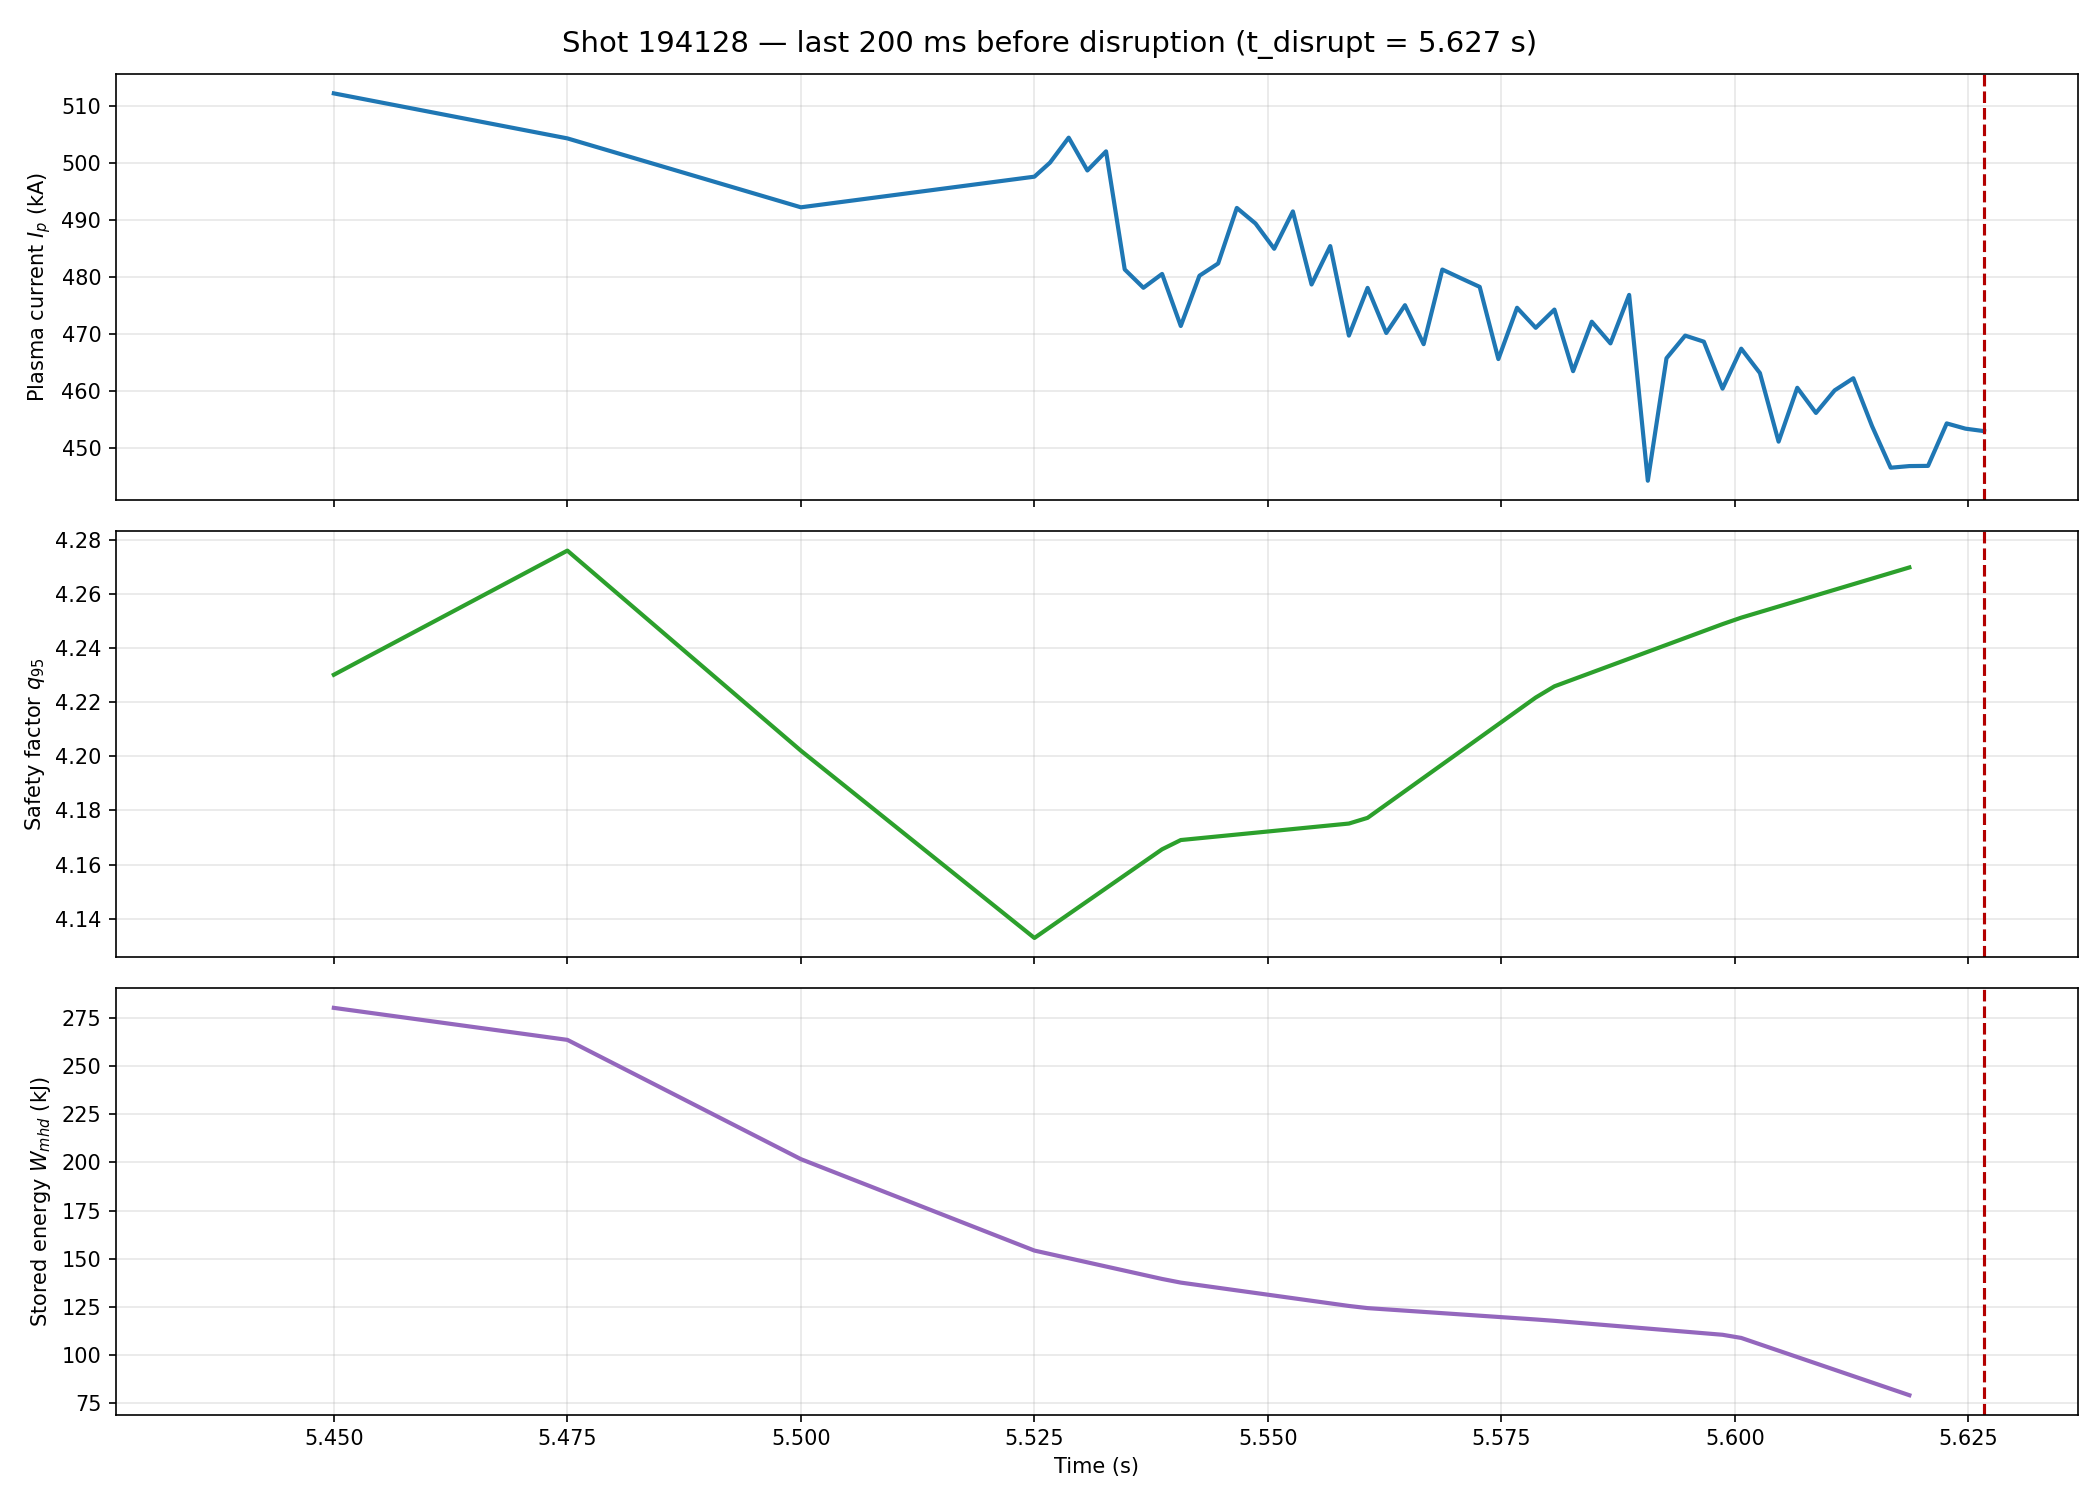

## What each parameter does

**Stored energy (Wmhd) — the dramatic collapse.** Wmhd falls from **280.3 kJ to 79.0 kJ, a −71.8% drop** over the window. The loss is fastest at the start: it halves from 280 kJ to 154 kJ in the first ~75 ms, then continues decaying steadily to 79 kJ. This is the **thermal quench** — the plasma loses confinement and its stored energy drains away on a millisecond timescale. It is the dominant, unmistakable precursor in this window.

**Plasma current (Ip) — a slower, oscillating decay.** Ip falls from **512.2 kA to 452.9 kA (−11.6%)** , but not monotonically — it fluctuates between ~445 and ~505 kA throughout, with the decay concentrated in the final ~20 ms (dropping to ~447 kA just before the disruption). The current quench is much slower than the thermal quench, which is the standard sequence: the thermal energy collapses first, and the current follows on a longer timescale. The plasma is still carrying ~450 kA at the disruption instant.

**q95 — a modest rise.** q95 dips to **4.13** around 5.5 s (coincident with the fastest Wmhd loss), then rises monotonically to **4.27** by the end of the window (+0.9% net). The rise is the expected consequence of the current decay — q95 scales roughly as 1/Ip, so as the plasma current drops, the edge safety factor rises.

**A data caveat worth noting:** q95 and Wmhd both become **None in the final ~6 ms** (5.6207 s onward) — EFIT reconstruction fails as the equilibrium is destroyed at the disruption itself. Ip continues to be recorded through the disruption instant. The chart drops those missing points per series; the trend descriptions above use the last valid EFIT values.

## Summary of the sequence

| Parameter | Start (5.45 s) | End | Change | Behaviour |
|---|---|---|---|---|
| Wmhd | 280.3 kJ | 79.0 kJ | **−71.8%** | Fast thermal quench, then steady drain |
| Ip | 512.2 kA | 452.9 kA | −11.6% | Slow, oscillating decay |
| q95 | 4.23 | 4.27 | +0.9% | Dip to 4.13, then monotonic rise |

The physics story is the classic disruption sequence: **thermal quench first** (Wmhd collapses by ~72%), **then current quench** (Ip decays more slowly and irregularly), with **q95 rising** as the current falls — and the equilibrium reconstruction failing in the final milliseconds as the plasma is destroyed.

In [8]:
%%ask --review
Pick one disrupted shot from the index. Plot the plasma current, q95 and
stored energy over the last 200 milliseconds before the disruption, and
describe what happens to each as the disruption approaches.

## Do disrupted and non-disrupted shots look different?

*comparison · **answerable***

I'll consult the d3d-disruption skill to use its query interface correctly.



The skill is clear on the comparison approach. Writing the comparison script now.



Running the comparison script.



The comparison ran cleanly — 10 disrupted vs 10 non-disrupted, Cohen's d on per-shot means. Now generating the chart.



The comparison is complete. Here is the full analysis.

## Disrupted vs non-disrupted shots in the index

**Group sizes** : 10 disrupted shots (194000, 194128, 194292, 194464, 194649, 194968, 195516, 195768, 195985, 196347) vs **10 non-disrupted** (194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687).

**Method** : for each of the 60 usable parameters, I took the per-shot mean over each shot's sampled time series, then computed **Cohen's d** (standardised difference of means) between the two groups of 10. Positive d = higher in disrupted shots; negative = lower.


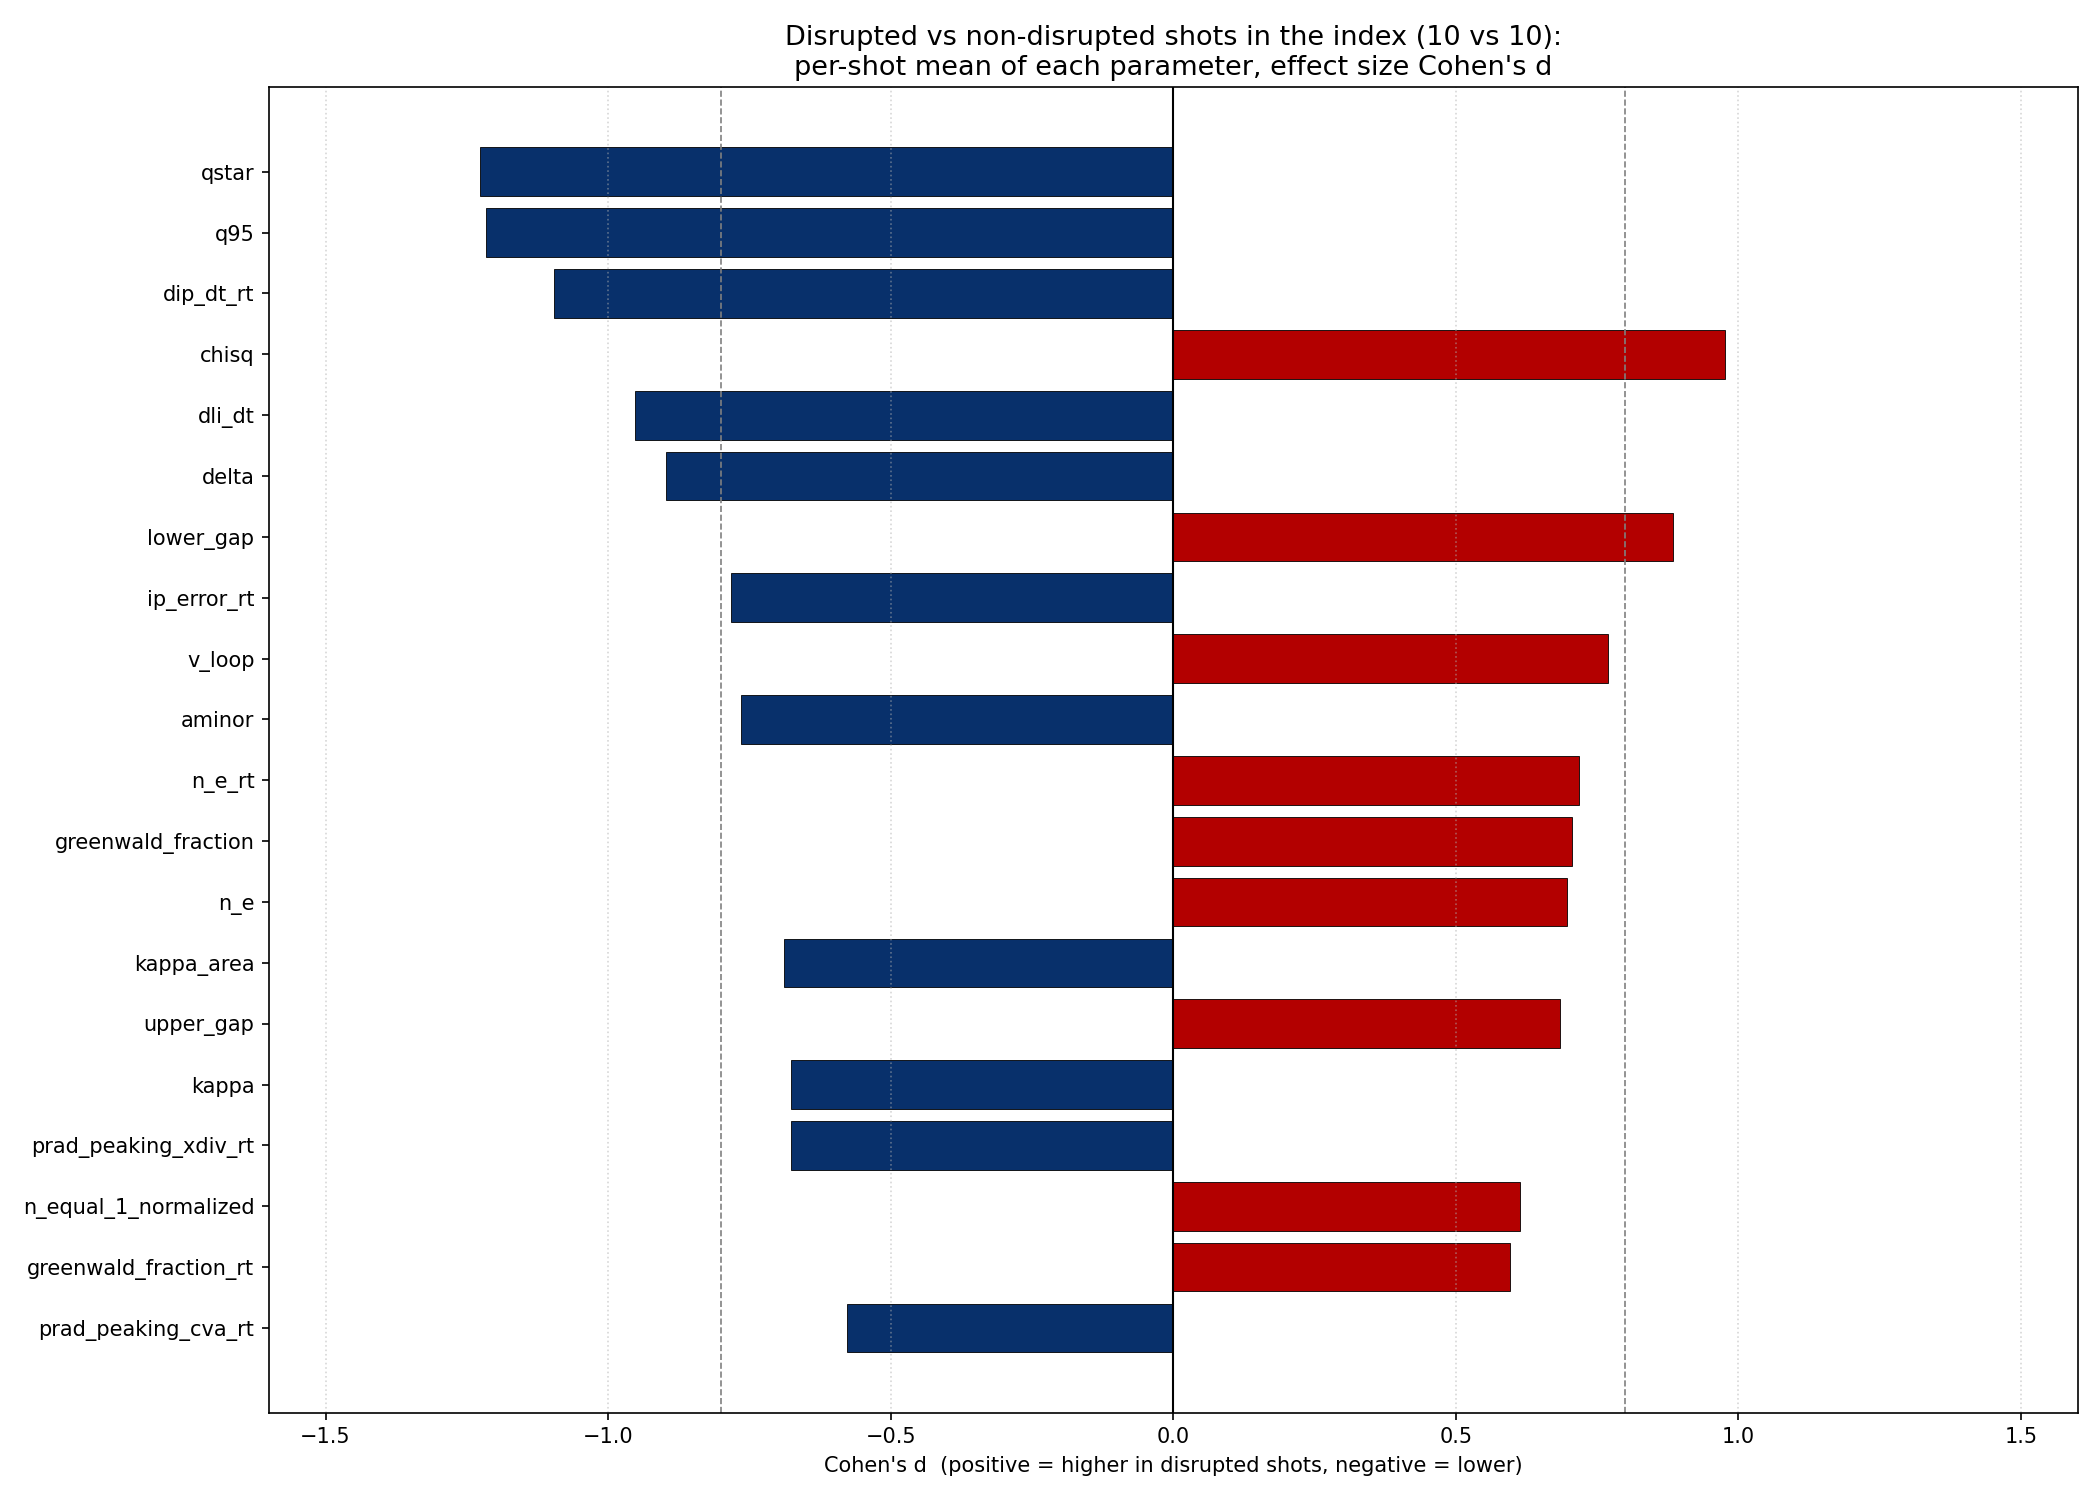

## The parameters that differ most

| Parameter | Mean (disrupted) | Mean (non-disrupted) | Cohen's d |
|---|---|---|---|
| qstar | 6.35 | 8.76 | **−1.23** |
| q95 | 4.77 | 6.44 | **−1.22** |
| dip_dt_rt (A/s) | −1.27e6 | +6.97e4 | **−1.10** |
| chisq | 28.5 | 19.4 | **+0.98** |
| dli_dt | −0.074 | +0.468 | **−0.95** |
| delta (triangularity) | 0.023 | 0.380 | **−0.90** |
| lower_gap | 0.319 | 0.207 | **+0.88** |
| ip_error_rt (A) | −2.74e6 | +1.78e6 | −0.78 |
| v_loop (V) | 1.055 | 0.562 | +0.77 |
| aminor (m) | 0.573 | 0.589 | −0.77 |
| n_e_rt (m⁻³) | 3.44e19 | 2.24e19 | +0.72 |
| greenwald_fraction | 0.508 | 0.326 | +0.71 |
| n_e (m⁻³) | 3.43e19 | 2.22e19 | +0.70 |
| kappa (elongation) | 1.57 | 1.69 | −0.68 |
| upper_gap | 0.410 | 0.295 | +0.69 |
| radiated_fraction | 0.927 | 0.293 | +0.54 |
| p_rad (W) | 2.06e6 | 1.48e6 | +0.54 |
| p_ohm (W) | 8.29e5 | 5.73e5 | +0.52 |

## What the differences say, in physics terms

The disrupted shots in this slice sit **closer to the operating limits** on almost every axis:

- **Current limit** : q95 and qstar are markedly lower (4.77 vs 6.44) — the disrupted shots run at higher current relative to the field, closer to the kink/current limit. The real-time current derivative `dip_dt_rt` is strongly negative (−1.27 MA/s) in the disrupted group versus slightly positive in the non-disrupted — the disrupted shots end in a current quench.
- **Density limit** : n_e and Greenwald fraction are ~50% higher (0.51 vs 0.33) — the disrupted shots run closer to the density limit.
- **Radiative collapse** : radiated fraction is 0.93 vs 0.29, with higher p_rad and p_ohm — the disrupted shots radiate a much larger share of their power, the classic precursor to a radiative/thermal collapse.
- **Shape** : the disrupted shots are much less shaped — triangularity δ ≈ 0.02 vs 0.38 (nearly circular vs strongly shaped) and lower elongation (1.57 vs 1.69) — and sit further from the wall (larger upper and lower gaps).
- **Equilibrium quality** : chisq is higher (28.5 vs 19.4), i.e. the EFIT reconstruction fits worse in the disrupted group, consistent with a deteriorating equilibrium.

## Caveats

- **This is the slice, not DIII-D.** These are 10 vs 10 deliberately balanced shots; the differences describe this index and are not a statistical sample of DIII-D disruptions.
- **Per-shot means include the disruption itself.** Parameters like `dip_dt_rt`, `dli_dt`, `ip_error_rt`, and `dwmhd_dt` are strongly affected by the final current/thermal quench within the shot, so part of their separation reflects the disruption event rather than a pre-disruption state. A precursor analysis would need to restrict to a pre-disruption window (e.g. `time_until_disrupt_max`).
- **n=1 mode results are mixed** : `n_equal_1_normalized` and `n_equal_1_mode` are higher in disrupted shots (d ≈ +0.6, +0.5) but `n1rms` is lower (d ≈ −0.4) — the two measures disagree, so I would not lean on the n=1 channel here.

In [9]:
%%ask --review
Compare the disrupted shots against the non-disrupted ones in this index.
Which parameters differ most between the two groups? Show the comparison and be
explicit about how many shots are in each group.

---
# 4. Knowing the limits

## How often do DIII-D shots disrupt?

*population · **correctly refused***

The honest answer is that this dataset cannot say. Twenty shots, deliberately
balanced ten and ten, is not a sample of DIII-D.

In [10]:
%%ask --review
What fraction of DIII-D shots disrupt? Use the disruption index to work
it out.

I'll verify the counts directly from the index before answering, since the answer hinges on what the index actually represents.



The skill is explicit that this index cannot answer a DIII-D-wide rate. Let me call the dedicated `disruption_rate()` function to get the exact refusal, and verify the underlying counts.



Running the check to confirm the counts and the refusal.



The check confirms the counts and the refusal. Here is the answer.

## The fraction cannot be worked out from this index

**The disruption index cannot answer "what fraction of DIII-D shots disrupt?"** — and the reason is structural, not a data gap.

The index holds **20 shots, 10 of them disrupted** — a **deliberately balanced 10/10 construction** , not a random sample of DIII-D. The skill's own `disruption_rate()` function exists precisely to refuse this question rather than let a number be inferred:

> This index holds 20 shots, 10 of them disrupted — deliberately balanced, not drawn at random from DIII-D. Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file.

## Why 10/20 is not a rate

- **The split is engineered.** The 20 shots were chosen to be 10 disrupted / 10 not. A 50% "disruption rate" computed from it is an artifact of the selection, not a measurement of DIII-D.
- **The index is not a sample.** It is a slice of shots that were run through disruption-py (v0.15.0.dev0, commit `9987784e`) and ingested. It was never drawn at random from the DIII-D archive, so no frequency statistic over it generalises.
- **Absence ≠ no disruption.** A shot not in the index is not a shot that didn't disrupt — it's a shot that wasn't ingested. So the denominator "all DIII-D shots" is not even defined by this file.

## What would answer the question

An archive-wide disruption rate needs the **d3drdb disruptions table** (the human-curated `disruptions` table that this index's labels come from) evaluated over a **defined shot population** — e.g. all plasma shots in a given campaign or date range — not this 20-shot index. That is a different dataset than the one this skill covers.

**Bottom line** : within this index, 10 of 20 shots disrupted — but that 50% describes the slice and nothing else. I will not present it as a DIII-D disruption fraction, because the data does not support that claim.

## What can't this dataset answer?

*scope · **answerable***

In [11]:
%%ask --review
Given everything above, what kinds of questions would this disruption
dataset NOT be able to answer, and what would be needed to answer them?

This is a synthesis of everything established across the previous turns, so no new queries are needed. Here is the full boundary analysis.

# What this disruption dataset cannot answer

The index is a **derived, curated slice** : 20 shots (10 disrupted / 10 not), 63 scalar time-series parameters (60 usable), produced by disruption-py **v0.15.0.dev0** (commit `9987784e`), with labels from the human-curated d3drdb disruptions table. Every limitation below follows from one of those properties.

## 1. Statistical / archive-wide questions
**Question type** : "What fraction of DIII-D shots disrupt?", "How often does DIII-D disrupt?", "What is the disruption probability in campaign X?", any precursor statistic meant to generalise to the machine.
**Why not** : 20 shots, deliberately balanced 10/10 — not a random sample; absence from the index ≠ no disruption, so the denominator isn't even defined.
**Needed** : the d3drdb disruptions table evaluated over a defined shot population (e.g. all plasma shots in a date/campaign range), or a large random sample run through disruption-py.

## 2. Questions about any shot outside the 20
**Question type** : "Did shot 123456 disrupt?", "What was Ip in shot X?", anything about a shot not in {194000…199687}.
**Why not** : the index only contains the 20 ingested shots.
**Needed** : d3d-shot-fetcher (raw waveforms), d3d-relational-db (shot catalog/metadata), or a fresh disruption-py run on that shot.

## 3. Raw waveform / high-frequency / ELM questions
**Question type** : D-alpha filterscope traces, ELM burst times and frequencies, MHD mode evolution at kHz, raw digitizer signals.
**Why not** : the index stores 63 derived scalars sampled at ~25 ms (2 ms near disruption), not raw waveforms.
**Needed** : d3d-filterscopes (D-alpha, ~50 kHz), d3d-shot-fetcher (PTDATA), d3d-elm-index (ELM labels), d3d-elm-phase-analysis.

## 4. Profile / spatial questions
**Question type** : radial profiles of Te, ne, rotation, q(r), pedestal structure, profile evolution through the shot.
**Why not** : all 63 parameters are scalars — q0, q95, qstar but no q(r); no Te/ne profiles.
**Needed** : Thomson / CER / ECE / charge-exchange profile diagnostics (d3d-shot-fetcher for efit01 psirz and related).

## 5. Phase-resolved questions
**Question type** : "Was this in ramp-up or flat-top?", pre-ELM vs post-ELM sorting of samples.
**Why not** : `time_domain` is unusable (constant 1.0 — the MA/A bug), and the index carries no ELM labels.
**Needed** : recompute phase from `ip`/`ip_prog` with correct units, or d3d-elm-index / d3d-elm-phase-analysis for ELM phase.

## 6. Questions about the 3 unusable parameters
**Question type** : current tracking error (`ip_error`), programmed-current ramp rate (`dipprog_dt`), shot phase (`time_domain`).
**Why not** : the MA/A unit bug in disruption-py v0.15.0.dev0 makes all three wrong.
**Needed** : recompute from raw `ip`/`ip_prog` with correct units; use `dipprog_dt_rt` for the ramp rate.

## 7. Definitive status of the 3 ambiguous shots
**Question type** : "Did 198244 / 198643 / 199062 disrupt?"
**Why not** : the curated label says no, but disruption-py's derived quench time says yes — the index cannot resolve the disagreement.
**Needed** : raw data, the d3drdb disruptions table, or manual inspection.

## 8. Signal meaning, shot metadata, catalog
**Question type** : "What does signal X mean?" (beyond the 63), pulse length, campaign, which shots exist in a range.
**Why not** : the index documents meaning/units only for its 63 parameters and carries no shot metadata.
**Needed** : d3d-relational-db (signal catalog, shot metadata, shot existence).

## 9. Other machines / other disruption-py versions
**Question type** : C-Mod, KSTAR, etc.; or behaviour under a different disruption-py version.
**Why not** : the index is DIII-D only and pinned to commit `9987784e`.
**Needed** : fresh disruption-py runs on those machines/versions.

## 10. The index's own construction
**Question type** : why these 20 shots, how they were selected, what the full source NetCDF contains beyond the 63 ingested parameters.
**Why not** : the index records its run provenance but not the selection rationale or the NetCDF's full variable set.
**Needed** : the original disruption-py run, the source NetCDF, or the person who built it.

## Summary

| Question type | Blocker | What's needed |
|---|---|---|
| Archive-wide rates / statistics | 20 balanced shots, not a sample | d3drdb disruptions table over a defined population |
| Any shot outside the 20 | Only 20 shots ingested | d3d-shot-fetcher / d3d-relational-db / fresh disruption-py run |
| Raw waveforms, ELMs, kHz MHD | 63 derived scalars, coarse sampling | d3d-filterscopes, d3d-shot-fetcher, d3d-elm-index |
| Radial profiles | Scalars only — no q(r), Te(r) | Thomson / CER / ECE profile diagnostics |
| Phase-resolved analysis | `time_domain` unusable, no ELM labels | recompute phase, d3d-elm-phase-analysis |
| The 3 unusable parameters | MA/A unit bug | recompute from raw `ip`/`ip_prog` |
| 3 ambiguous shots | label vs derived quench time disagree | raw data / d3drdb |
| Signal meaning / metadata | only 63 params documented | d3d-relational-db |
| Other machines / versions | DIII-D only, pinned version | fresh disruption-py runs |
| Index construction | provenance not recorded | original run / source NetCDF |

**The one-line summary** : this dataset answers *"what do the 63 disruption-py parameters do, for these 20 specific shots, and how do they behave as a disruption approaches"* — and nothing that requires a broader population, raw waveforms, spatial profiles, or shot-phase context. Each of those needs a different dataset or a fresh disruption-py run.